### Final Project Fraud / Anomaly Detection System (end-to-end)

In this project I'll be creating a credit card anomaly detection, using everything I have learned from this past few months the main problematic that I will be solving is 

Detecting fraudulent transactions in a highly unbalanced dataset by comparing:
  - supervised models
  - anomaly models
  - real-world business tradeoffs
  - model interpretability

In [2]:
# Basic imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Reading the fraudulent transaction data set from (https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/input)
df = pd.read_csv('./creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


As seen, this dataset is really unbalanced since only 0.172% (492 transactions) of the transactions are confirmed frauds, this project will be key in understanding how to handle class imbalance in machine learning. 

If I run this model with my past knoledge of ML algorithms I will get a 98 accuracy with no problem, but this is misleading since I have a data set with such high class imbalance.

### Exploratory Data Analysis From The Dataset

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Scatter Plotes

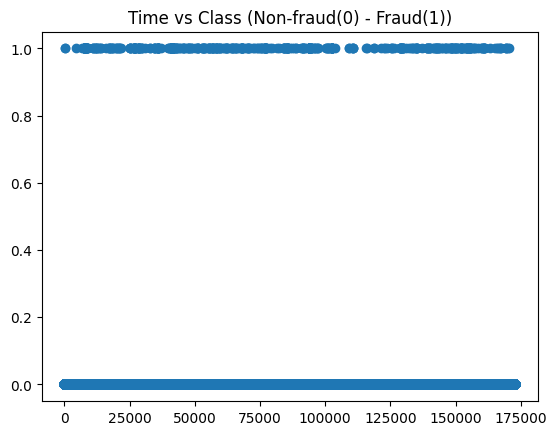

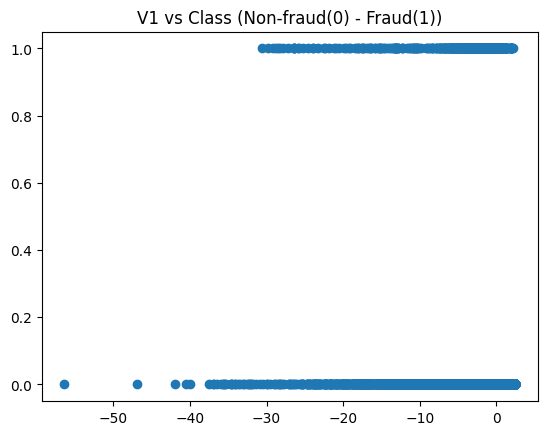

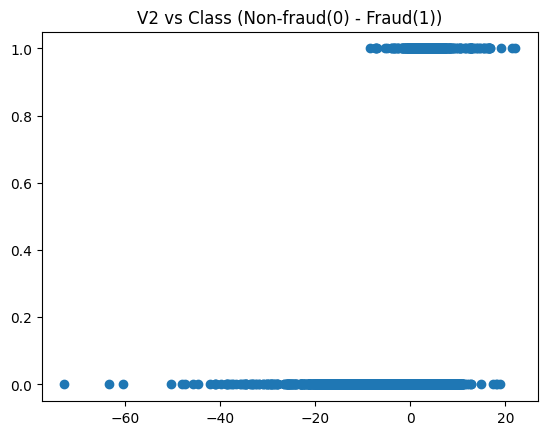

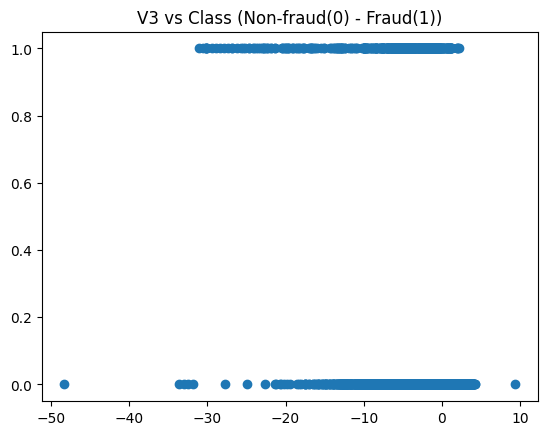

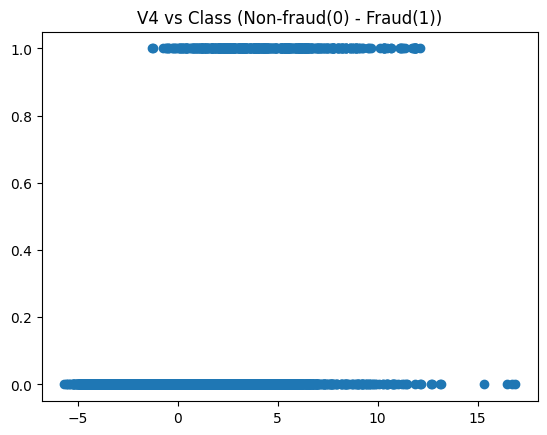

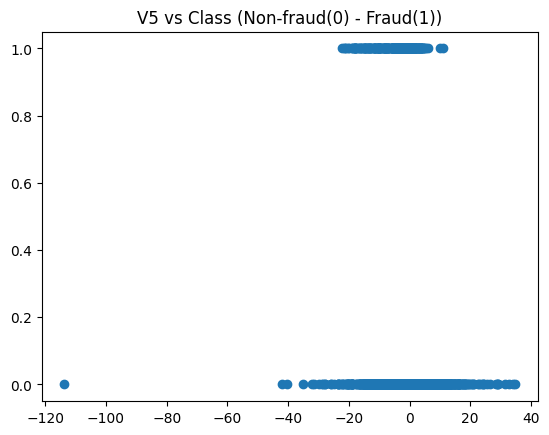

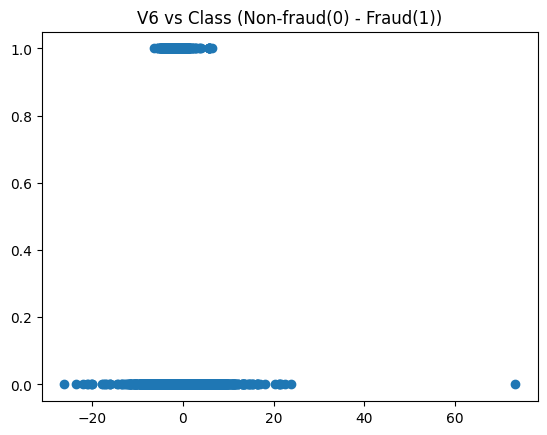

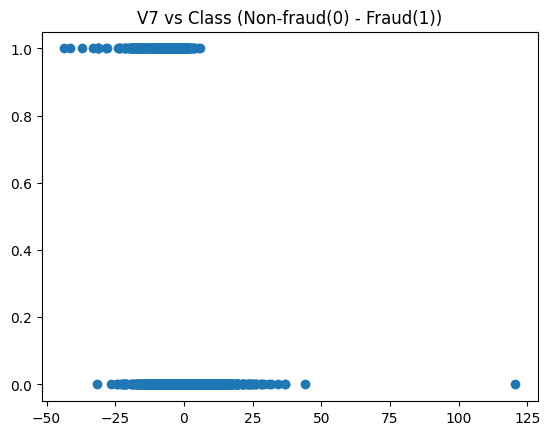

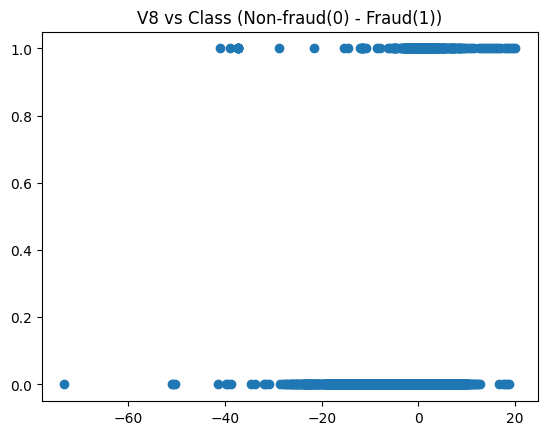

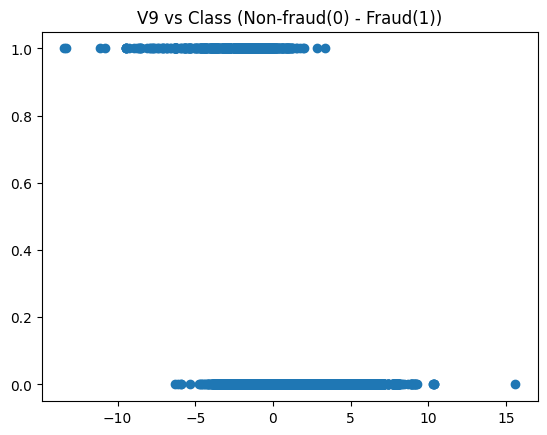

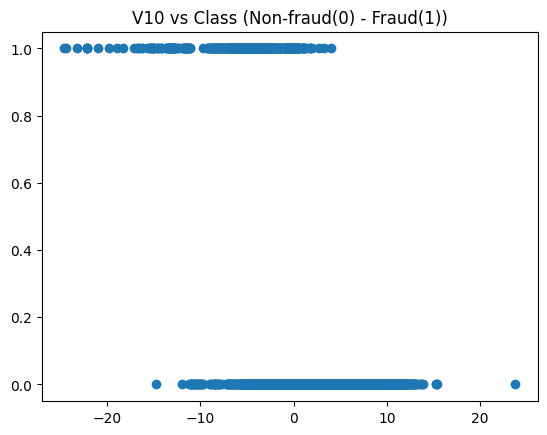

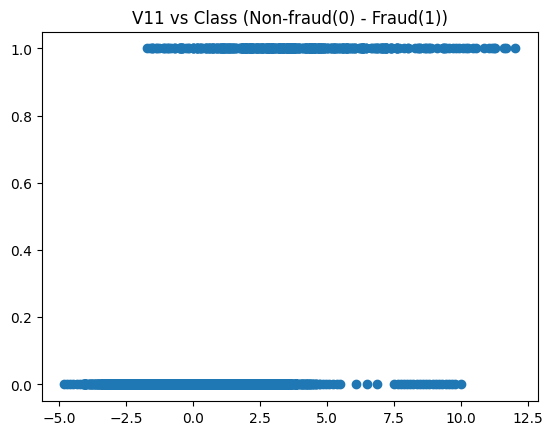

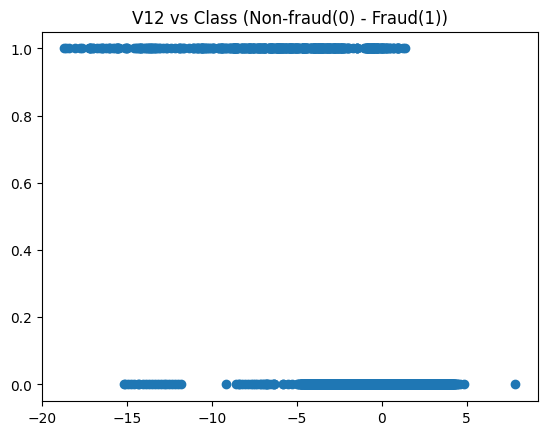

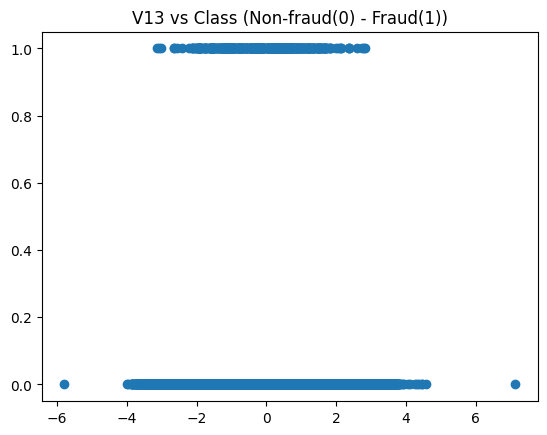

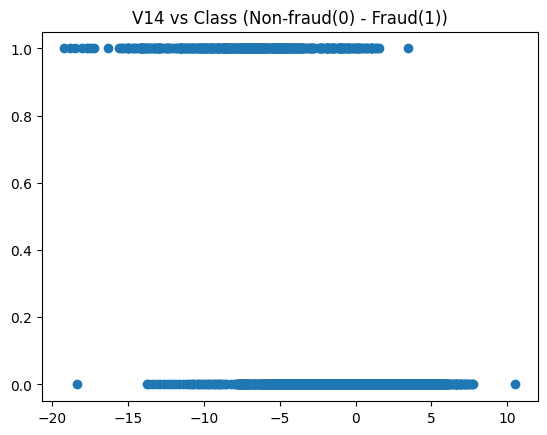

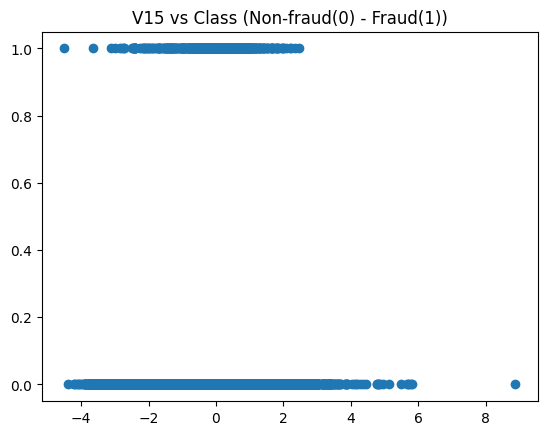

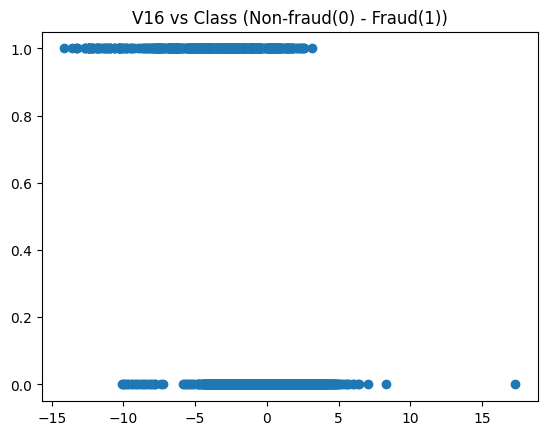

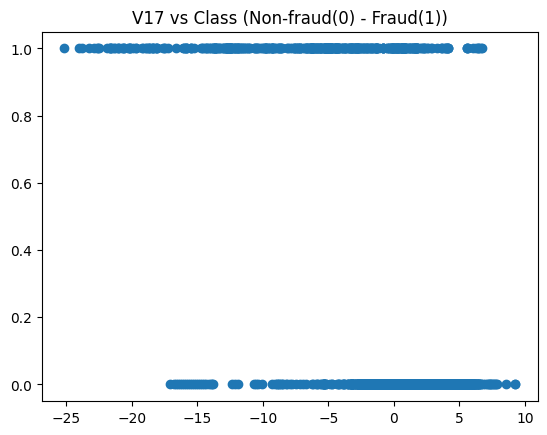

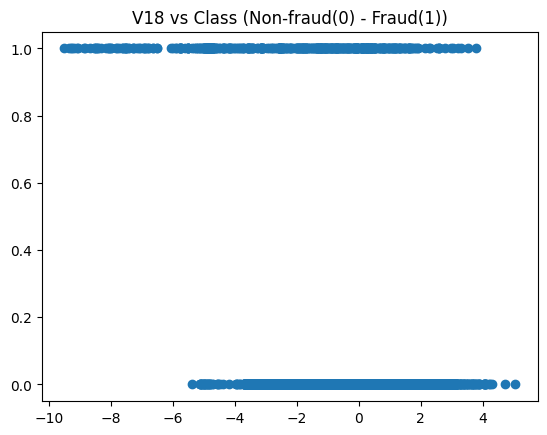

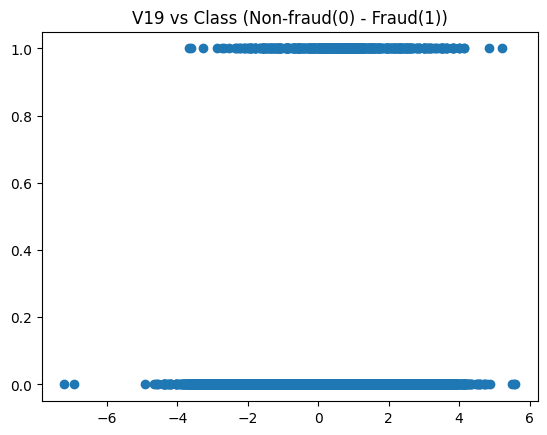

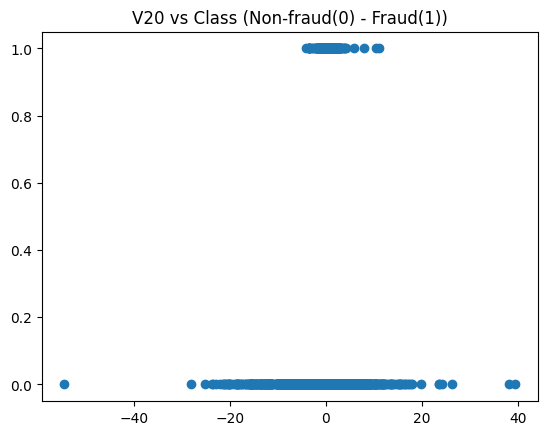

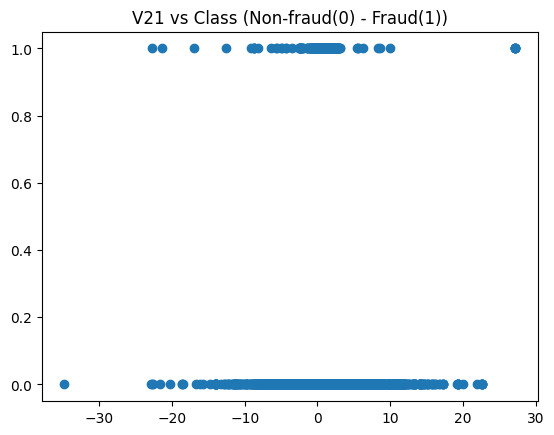

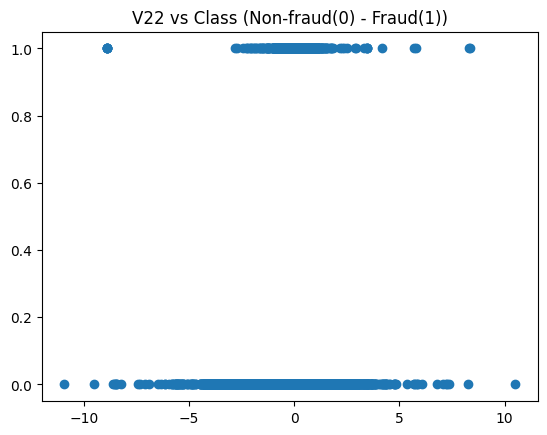

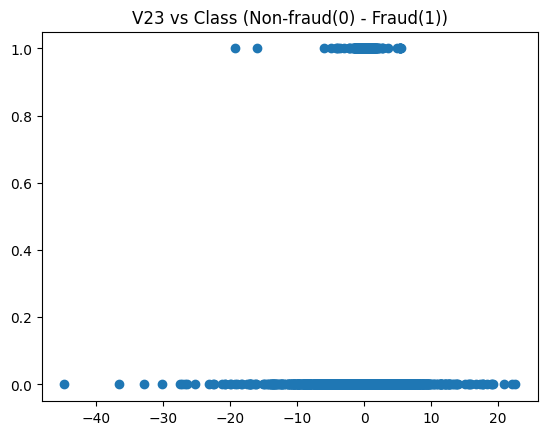

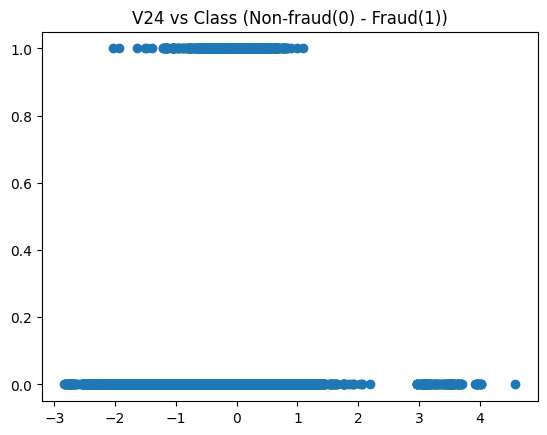

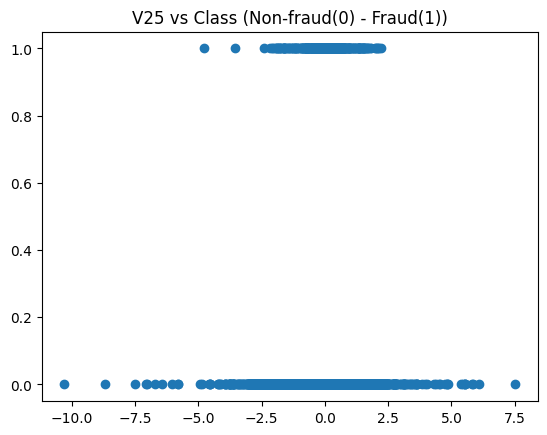

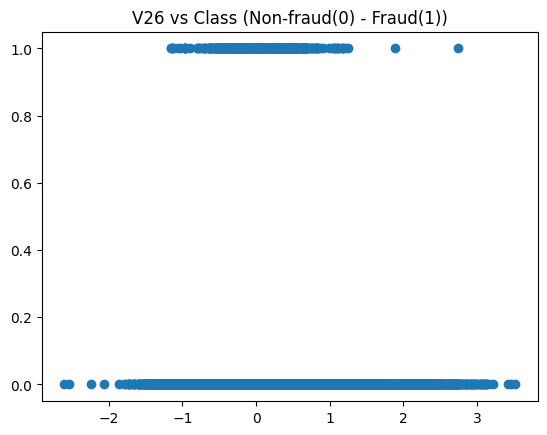

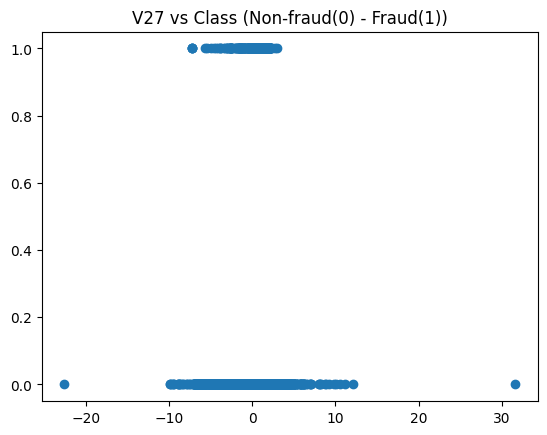

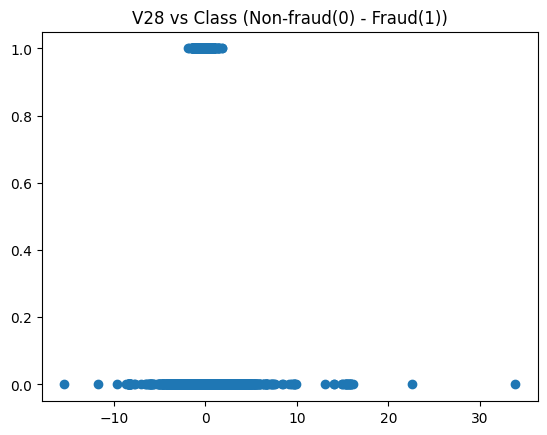

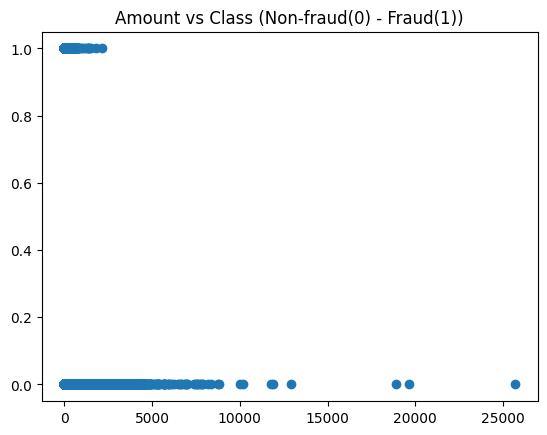

In [5]:
features = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Y = df['Class']

for f in range(len(features)):
    feature_name = features[f]
    plt.scatter(df[feature_name], Y)
    plt.title(feature_name + " vs Class (Non-fraud(0) - Fraud(1))")
    plt.show()

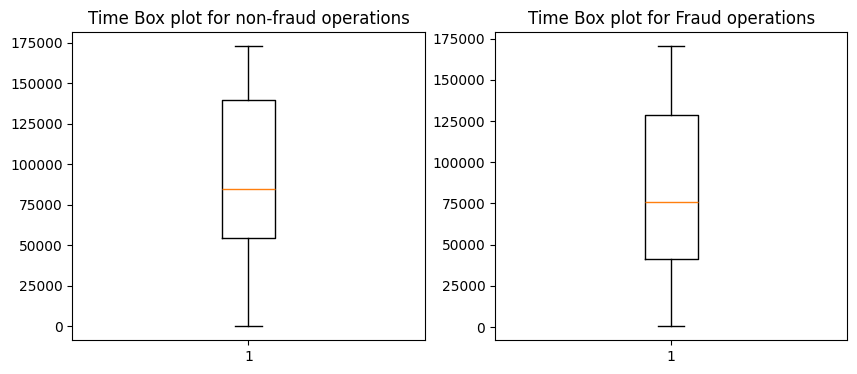

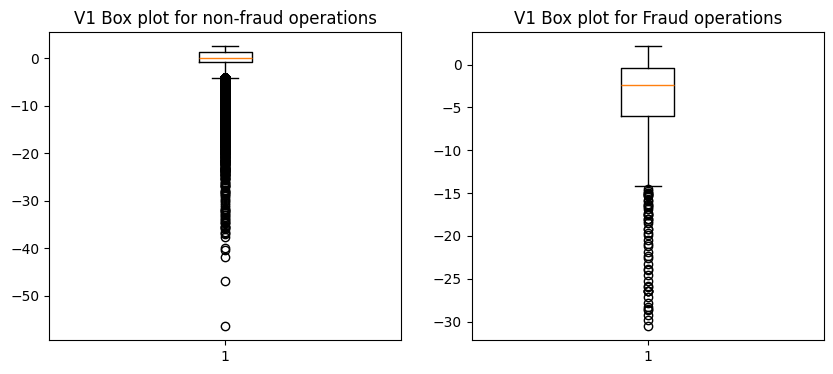

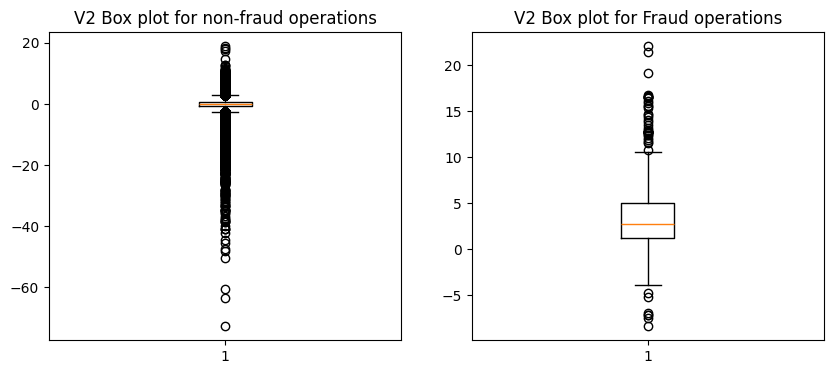

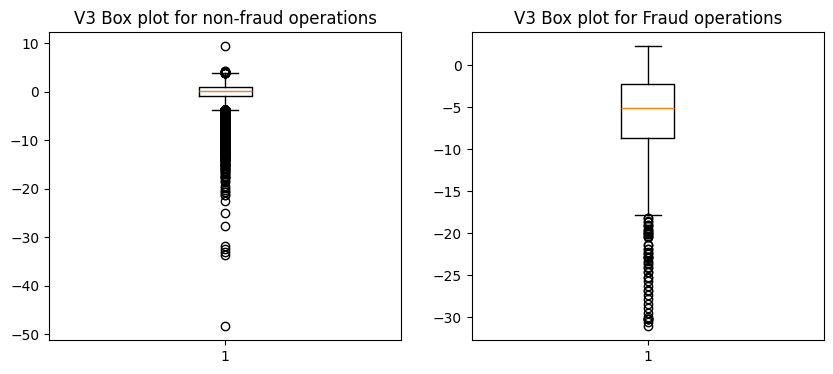

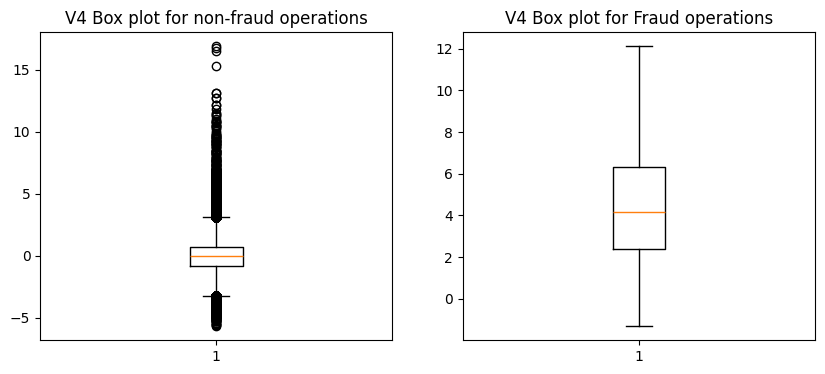

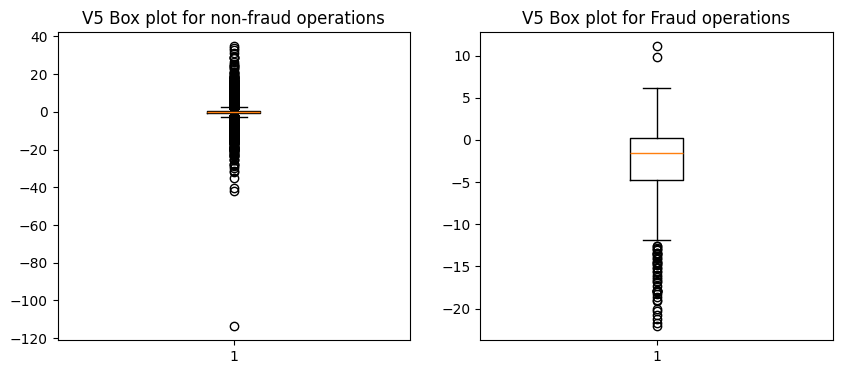

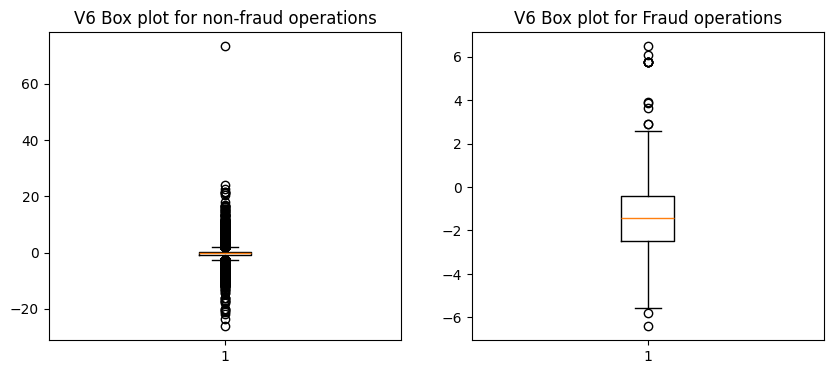

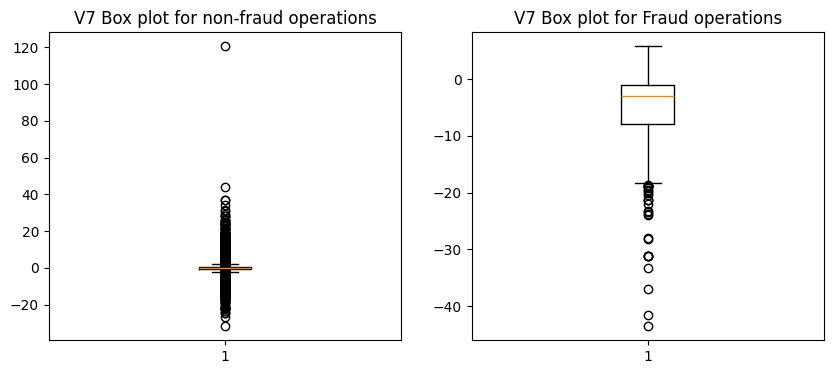

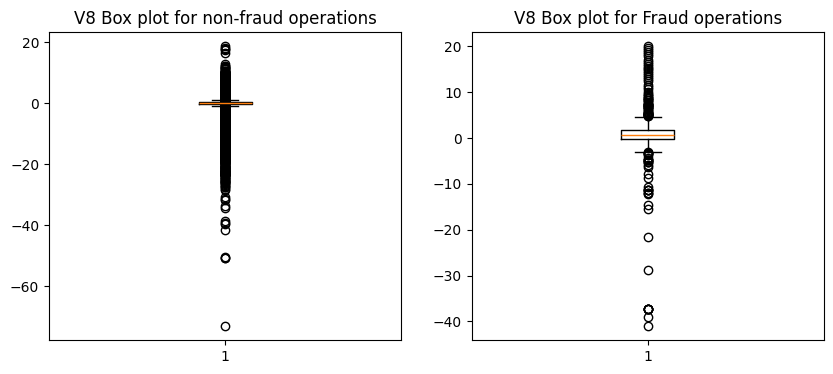

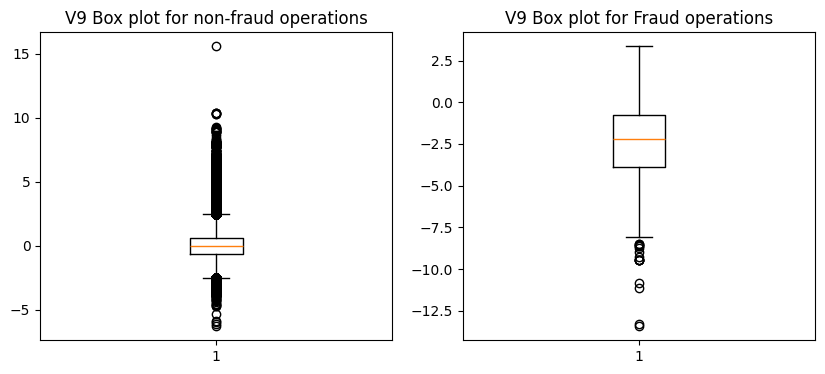

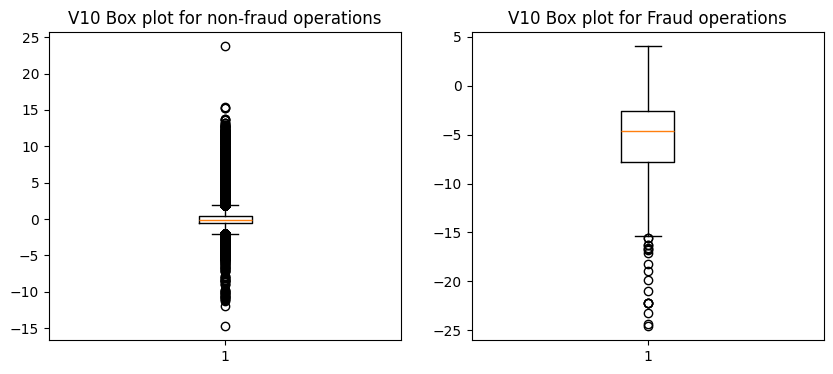

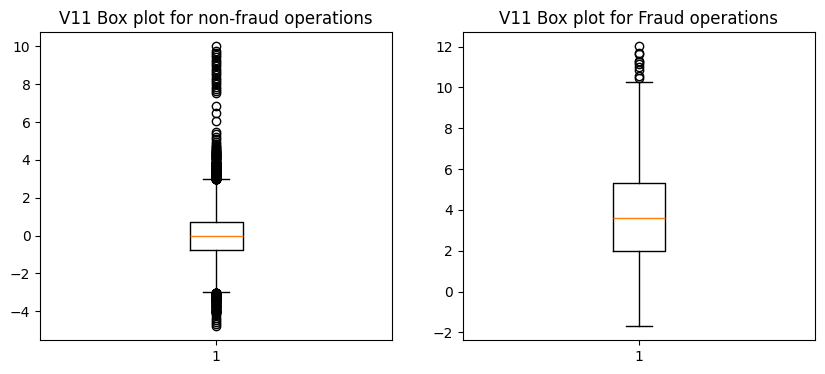

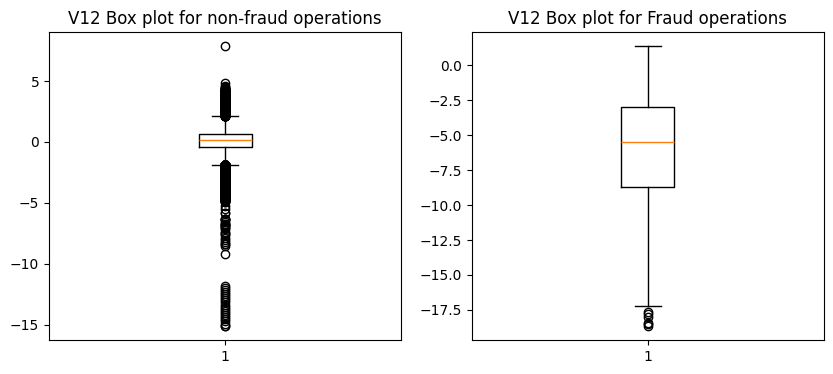

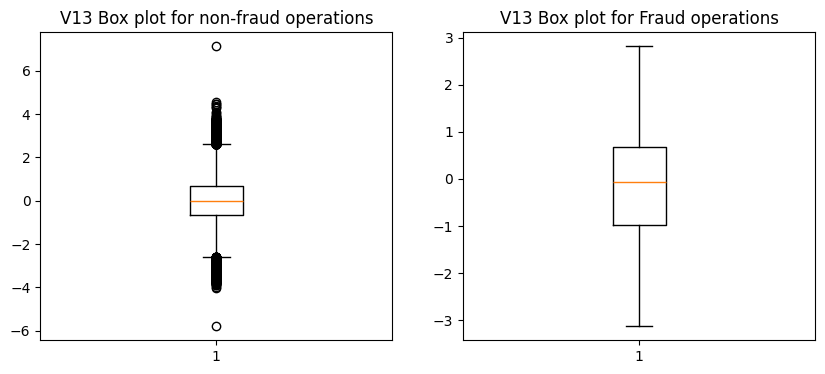

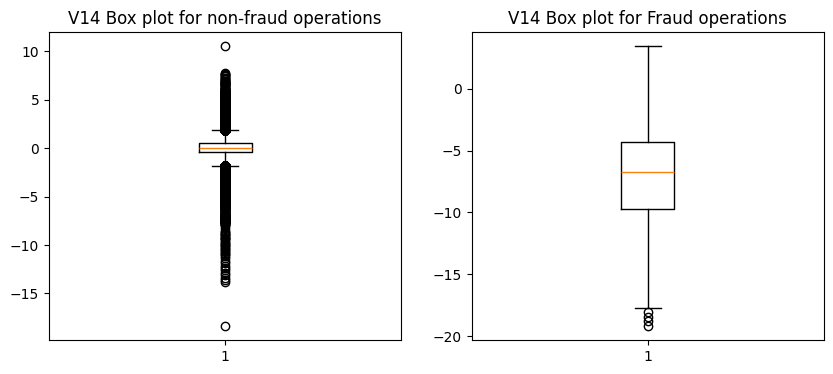

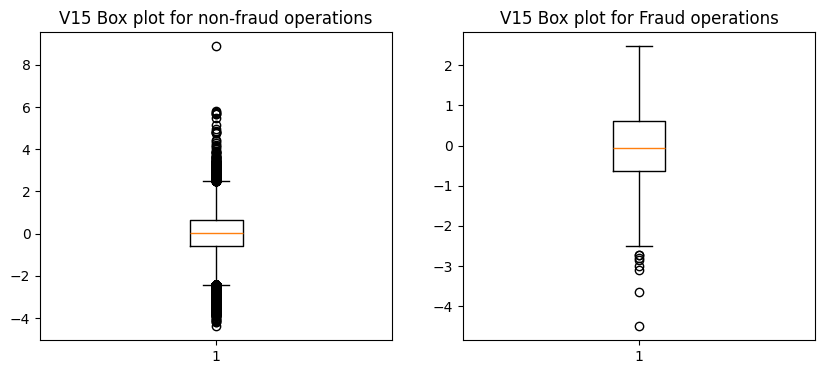

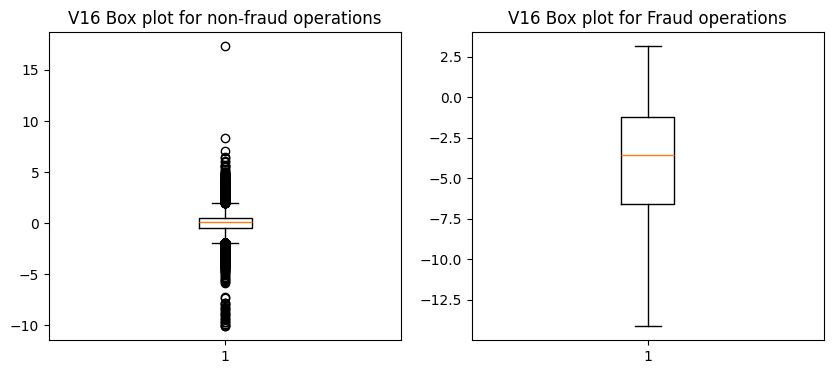

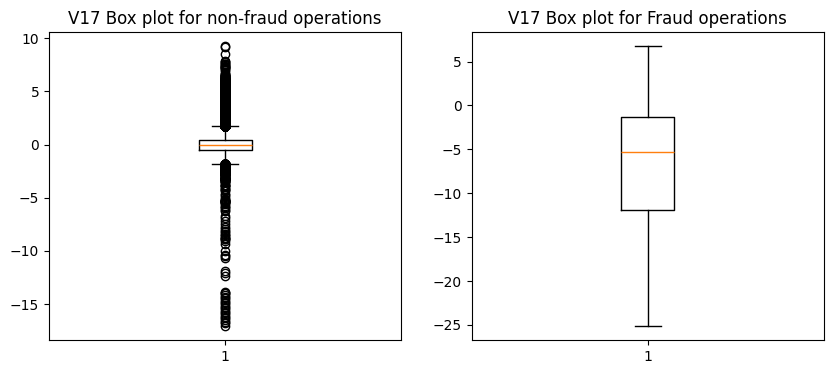

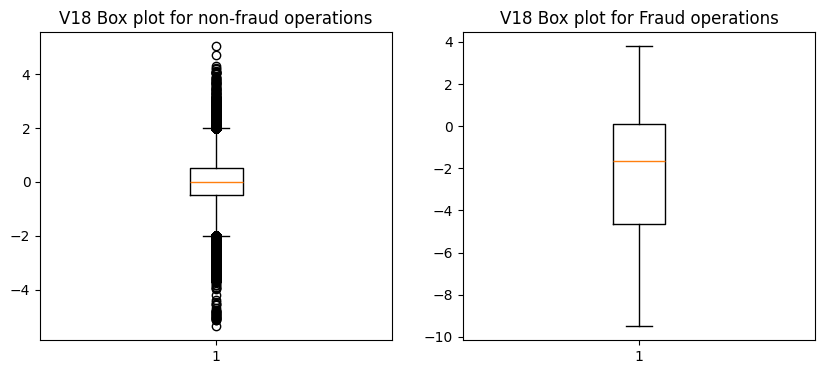

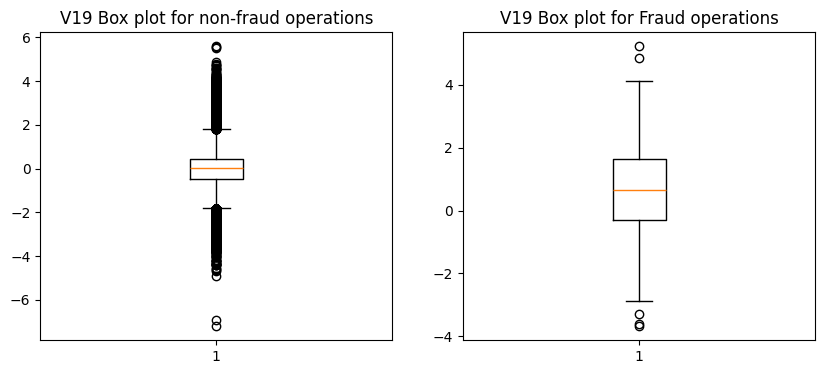

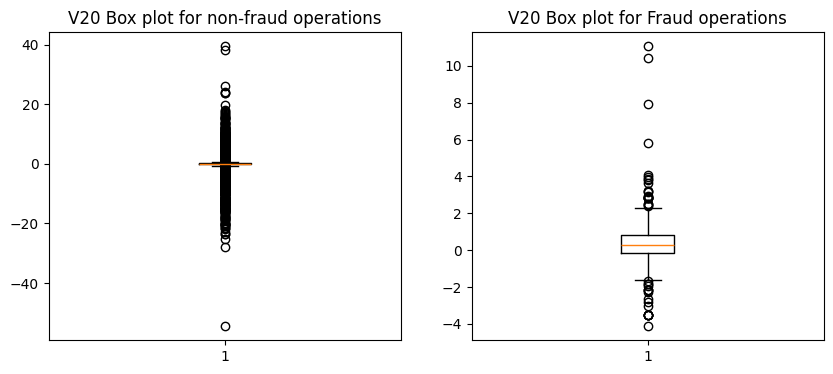

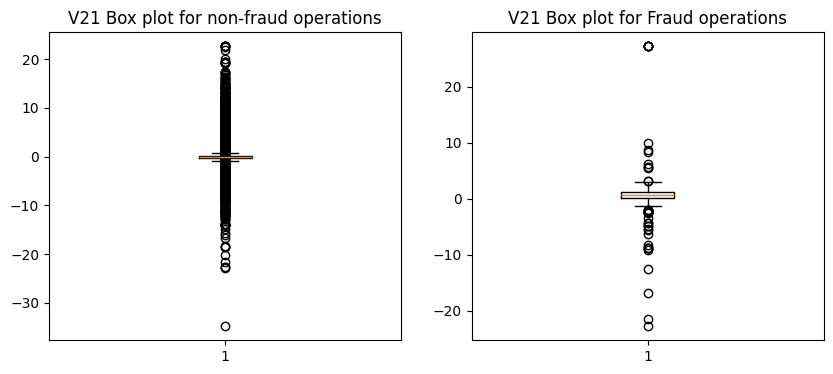

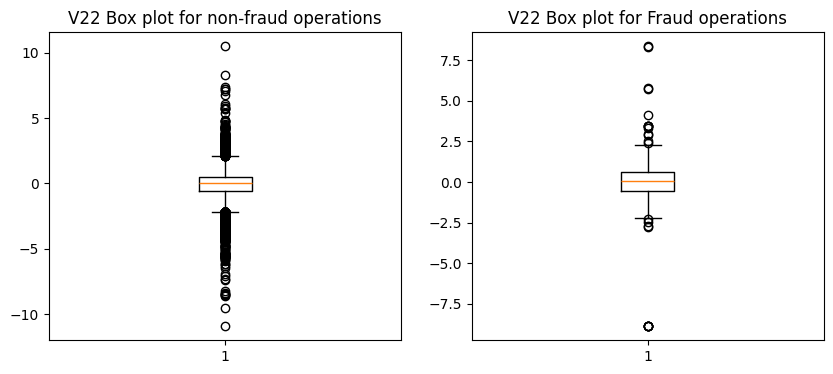

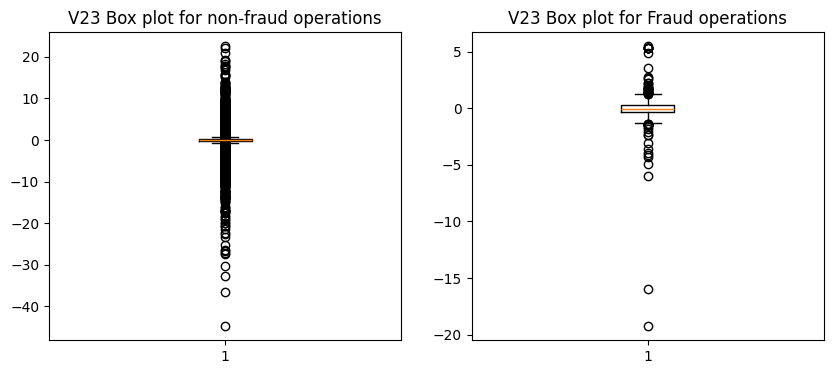

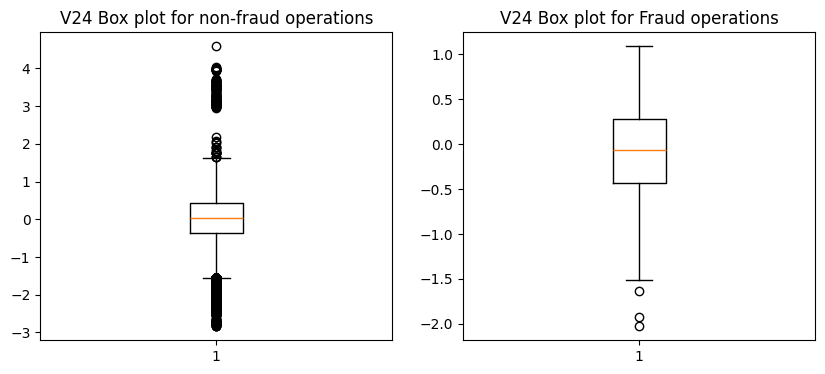

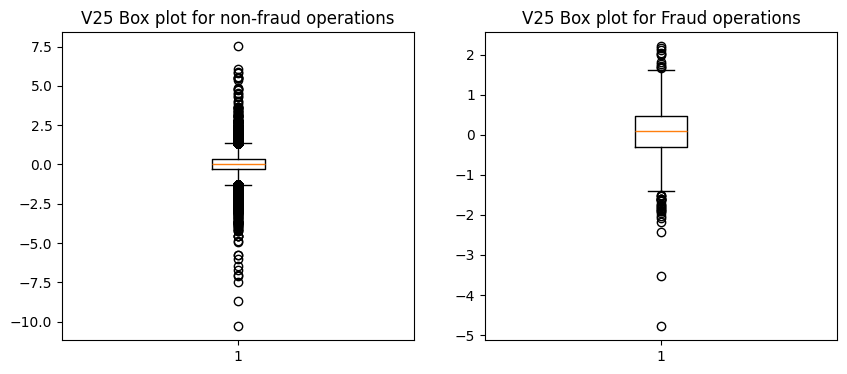

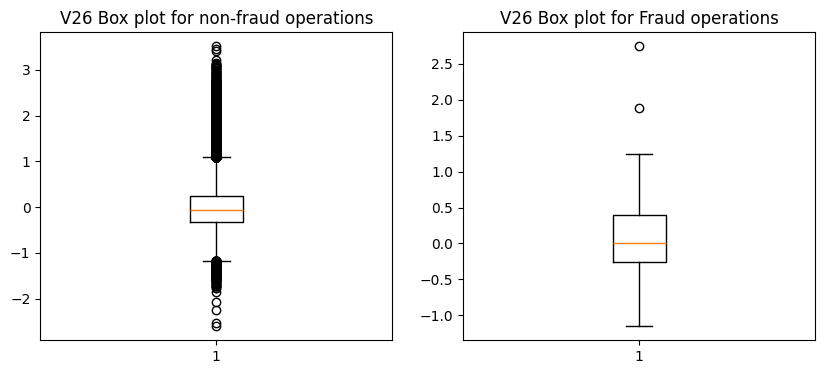

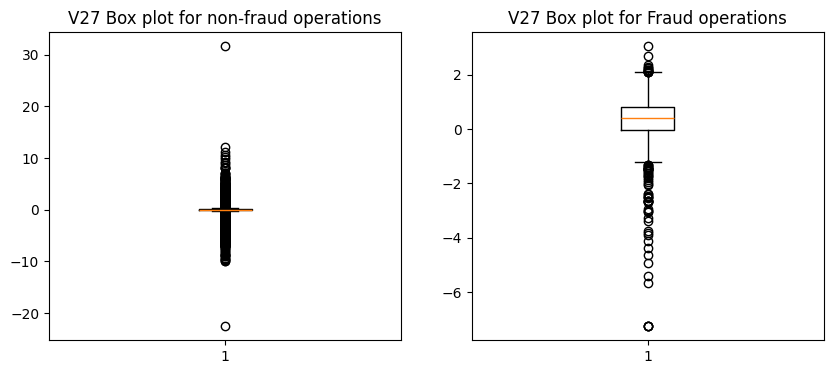

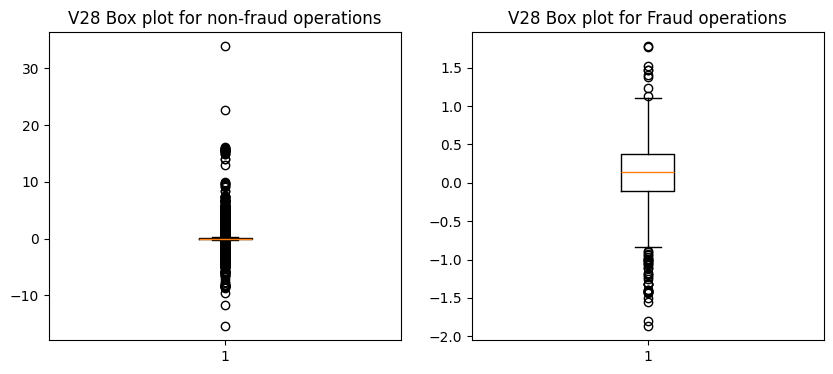

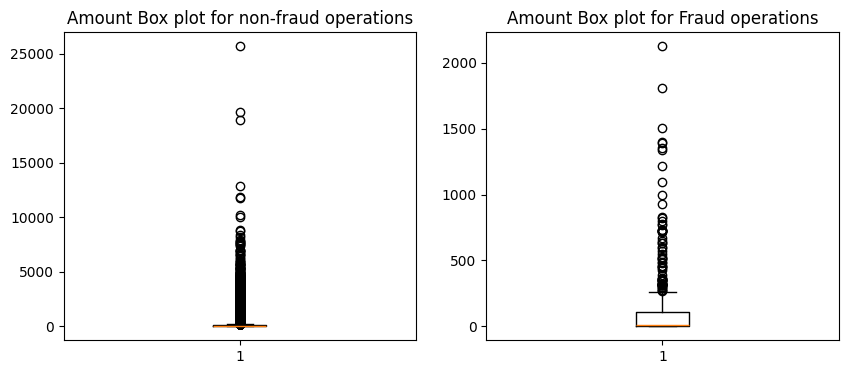

In [12]:
for f in range(len(features)):
    feature_name = features[f]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.boxplot(df.query('Class == 0')[feature_name])
    ax1.set_title(feature_name + " Box plot for non-fraud operations")
    ax2.boxplot(df.query('Class == 1')[feature_name])
    ax2.set_title(feature_name + " Box plot for Fraud operations")
    plt.show()

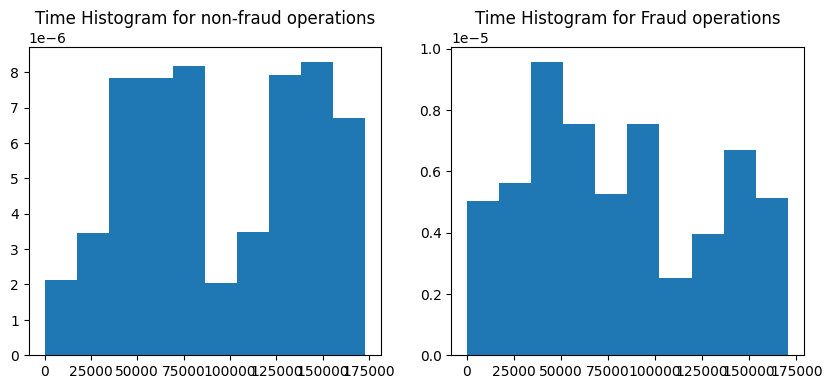

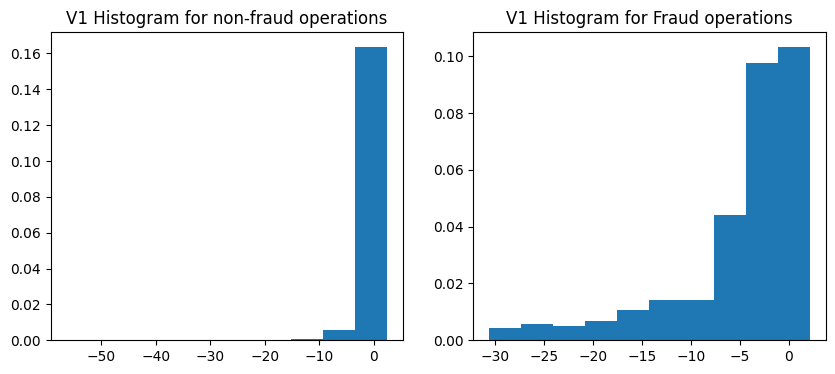

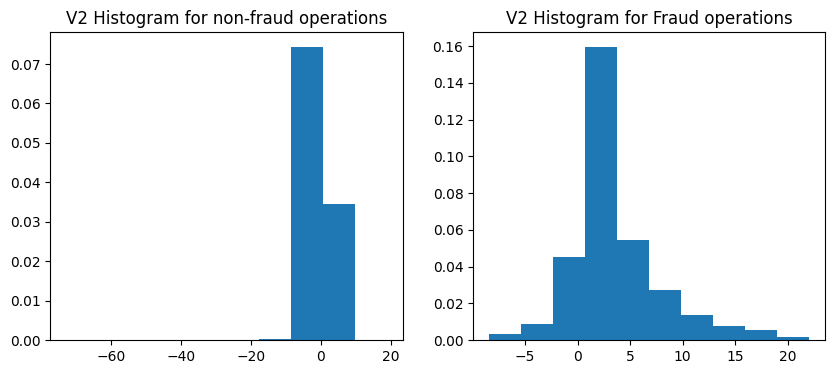

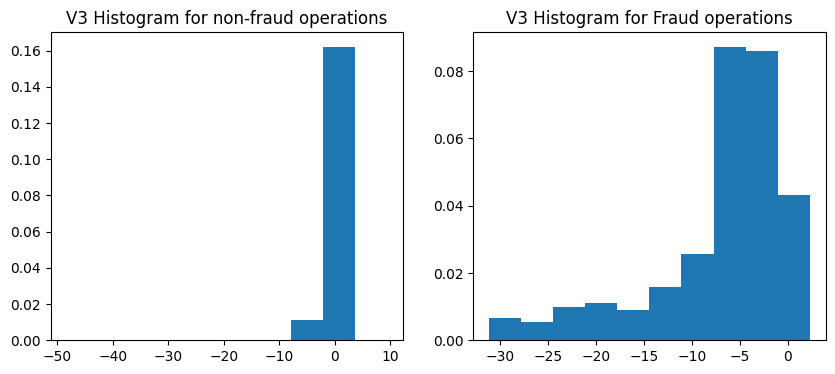

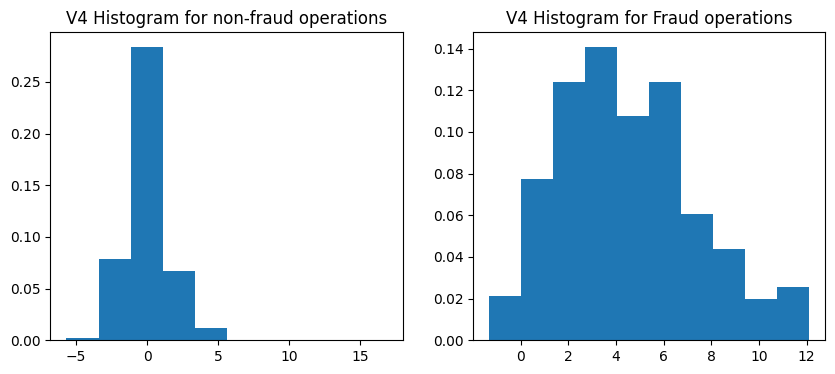

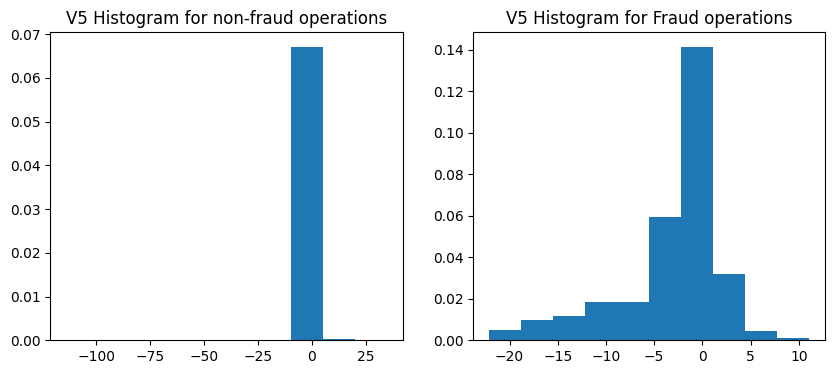

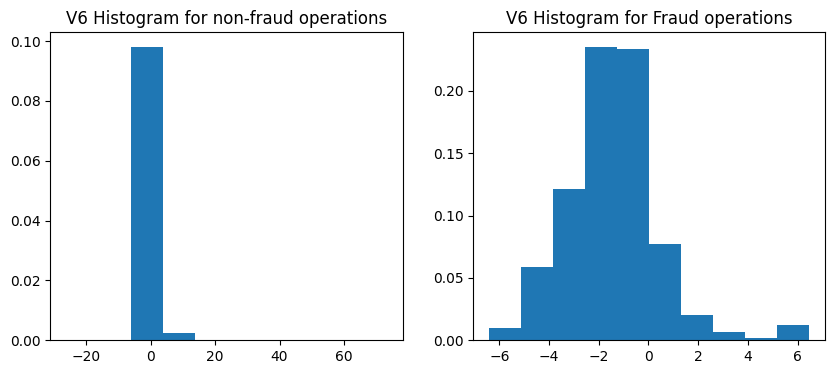

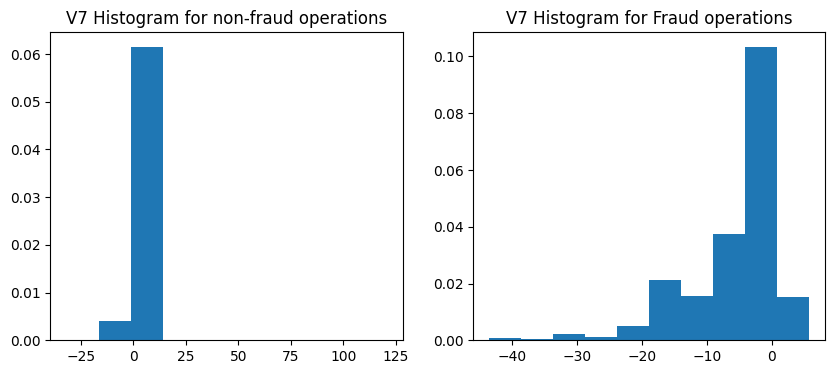

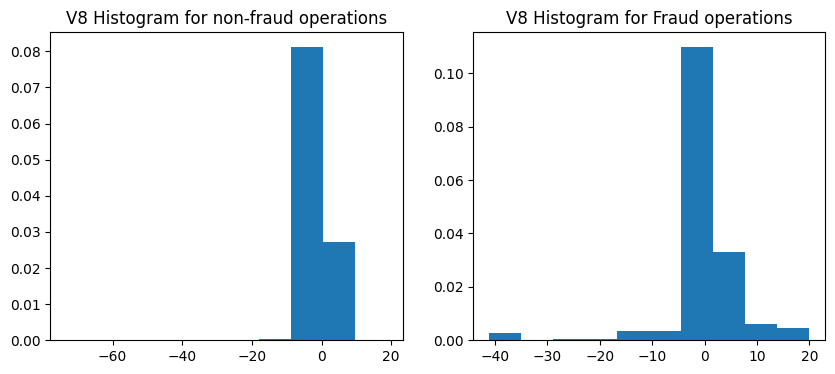

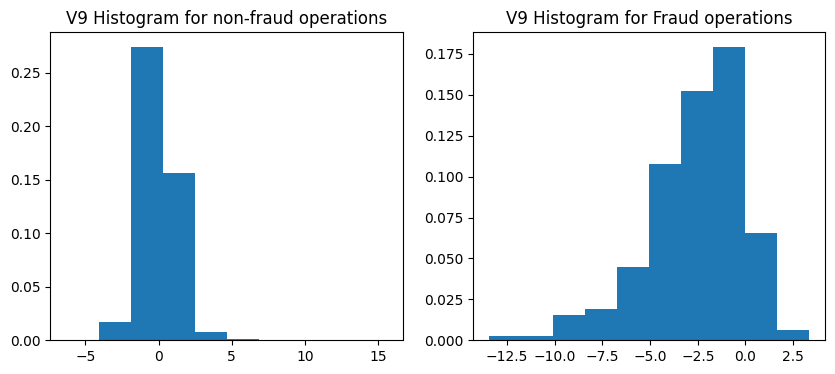

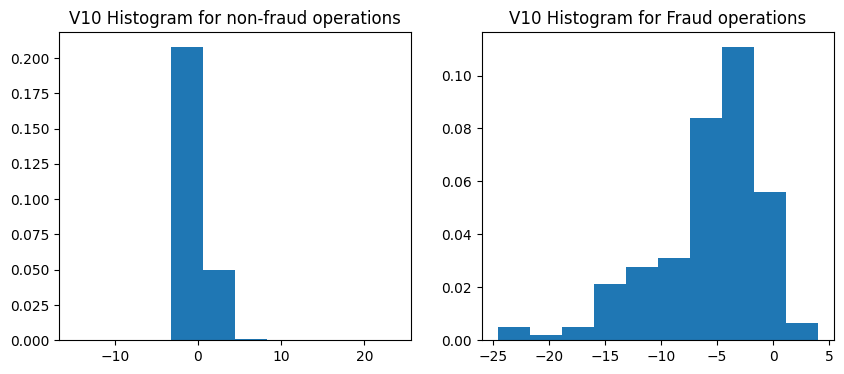

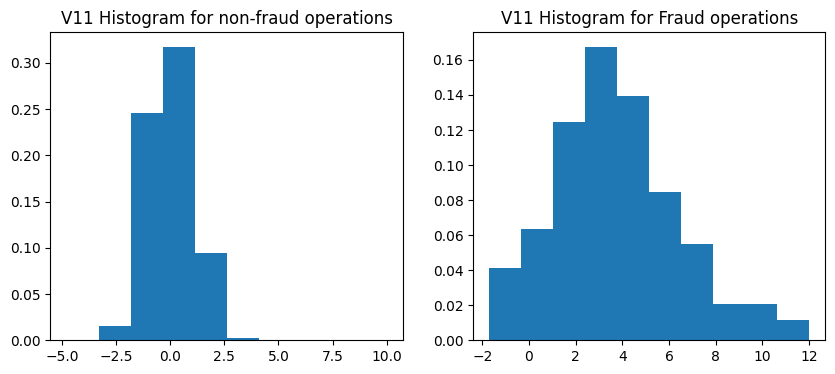

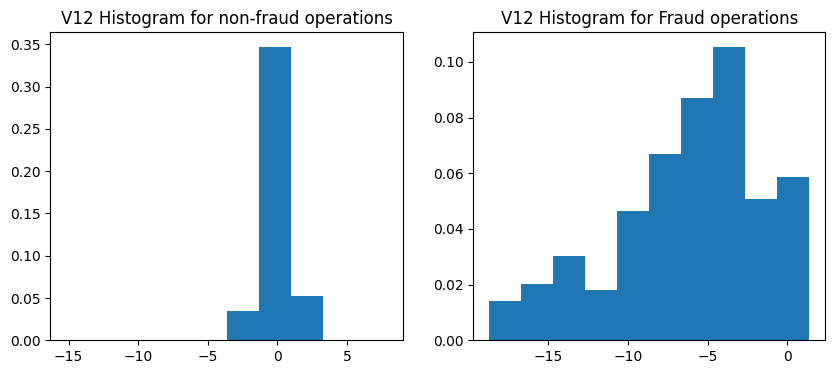

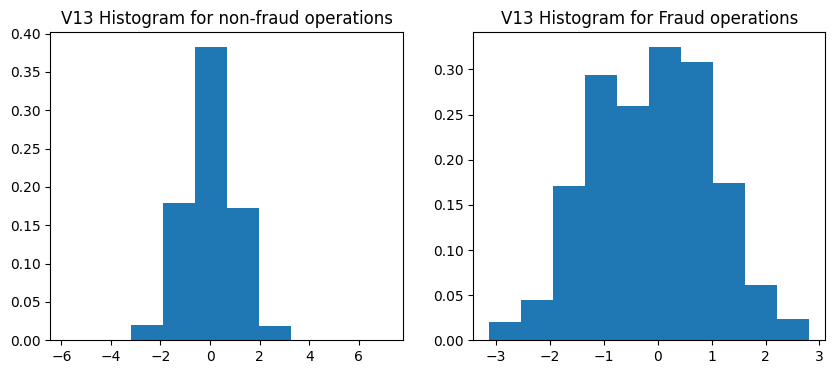

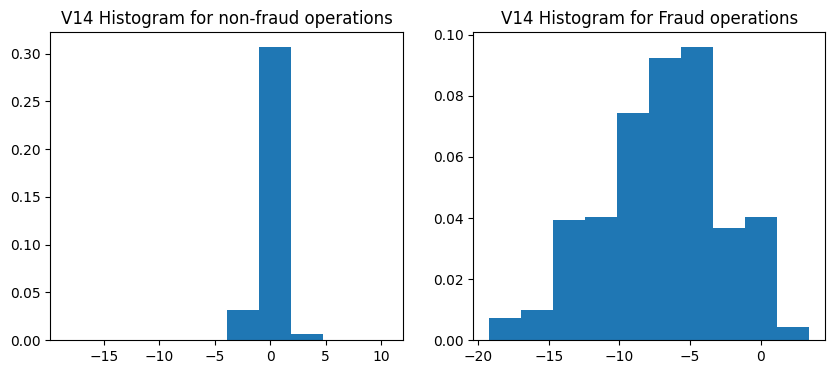

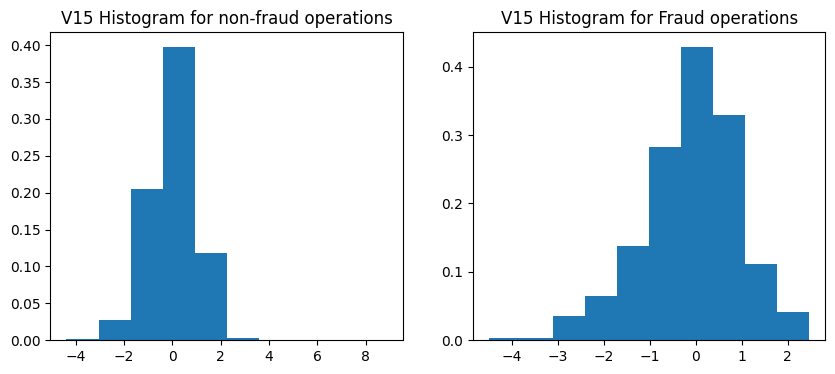

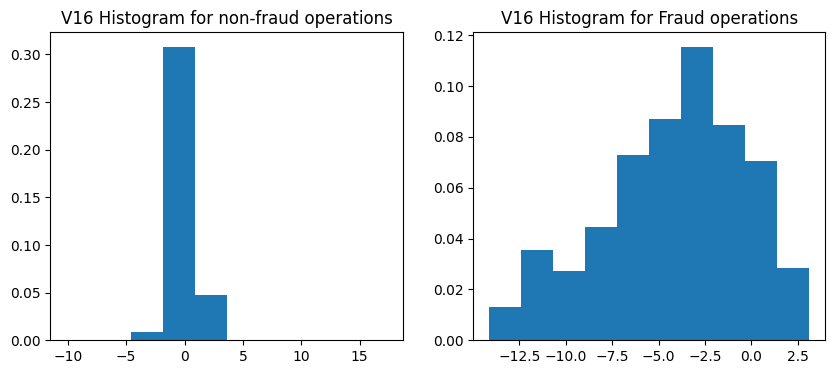

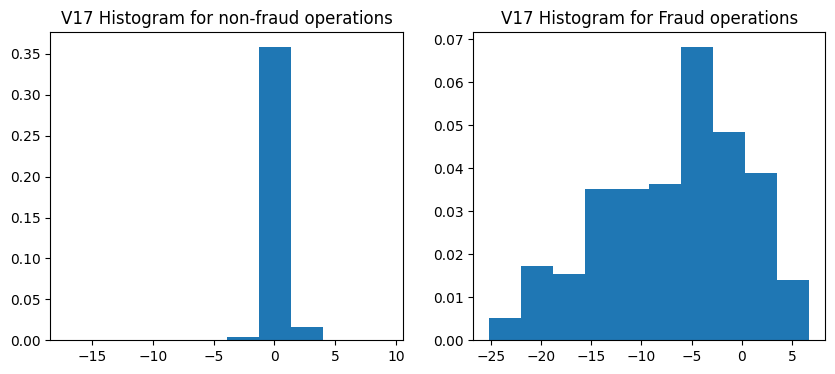

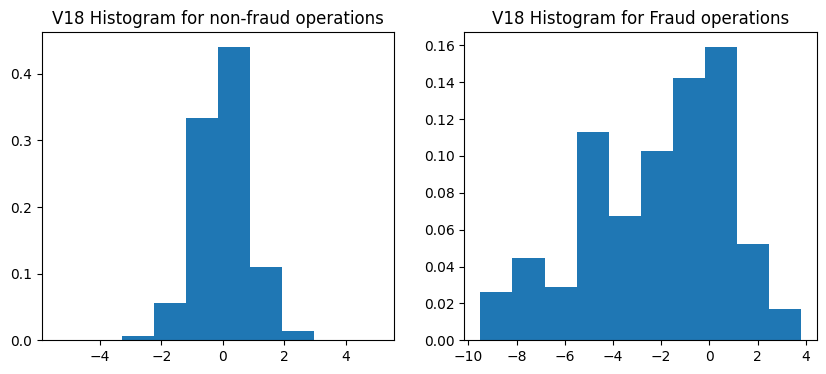

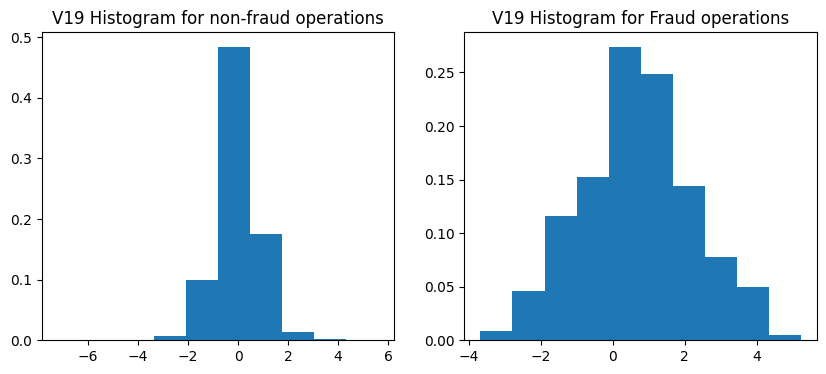

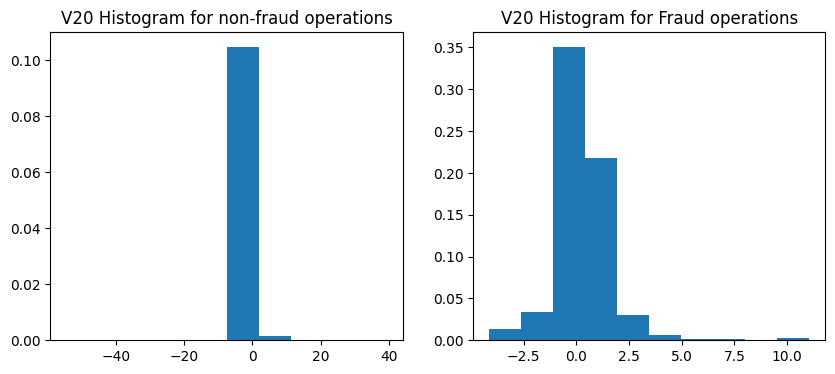

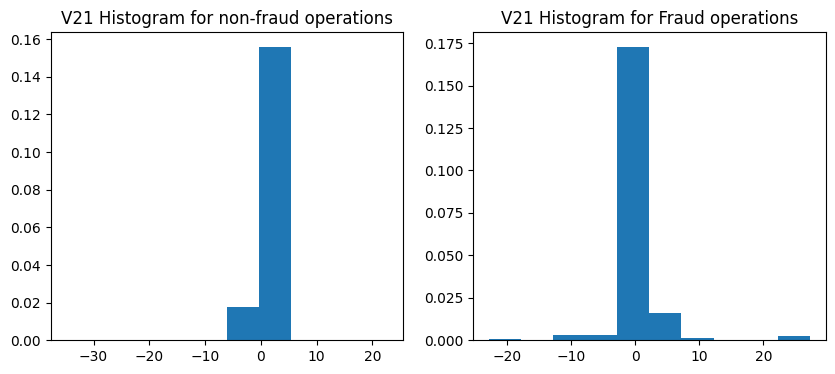

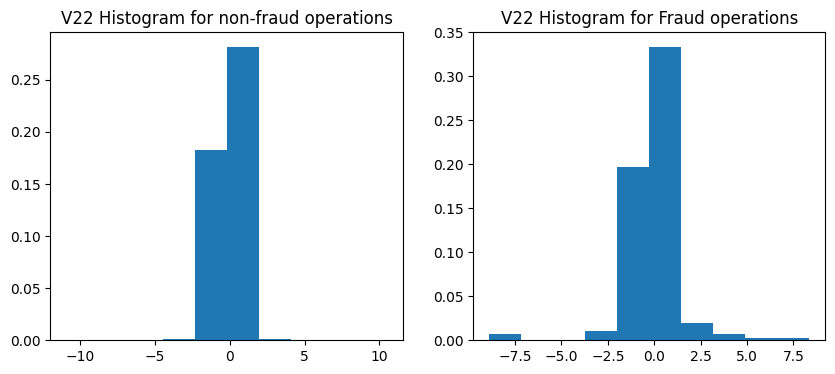

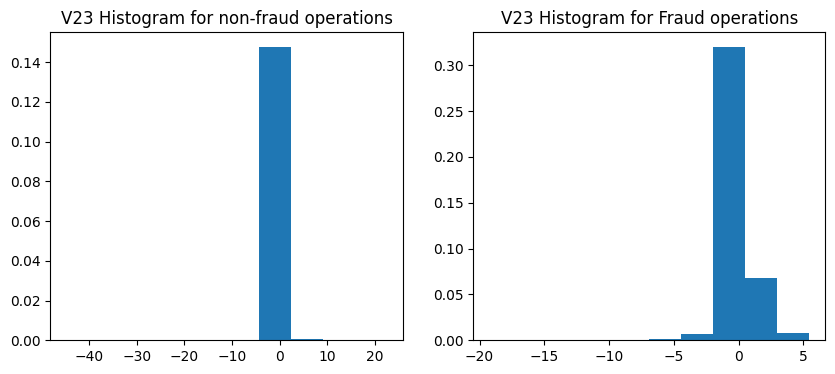

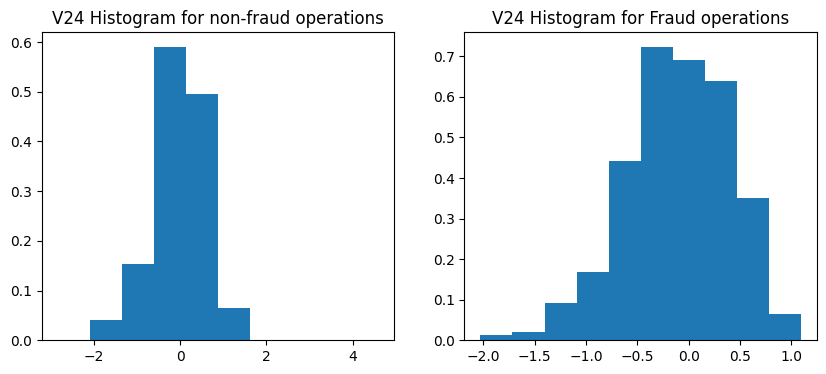

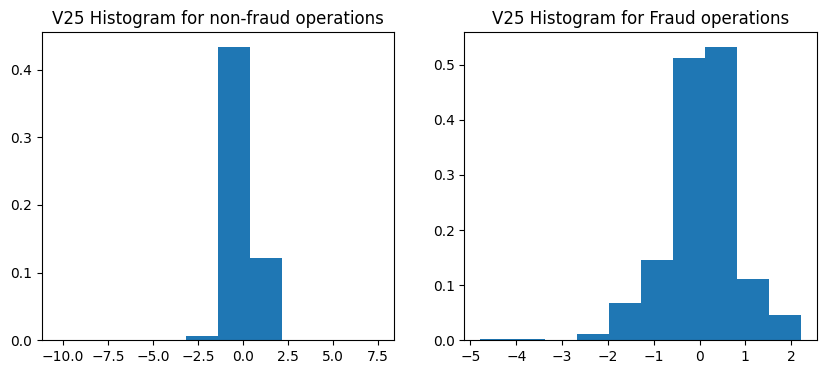

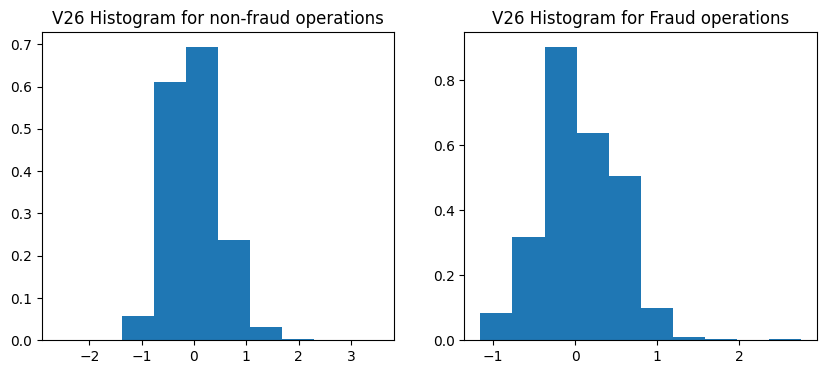

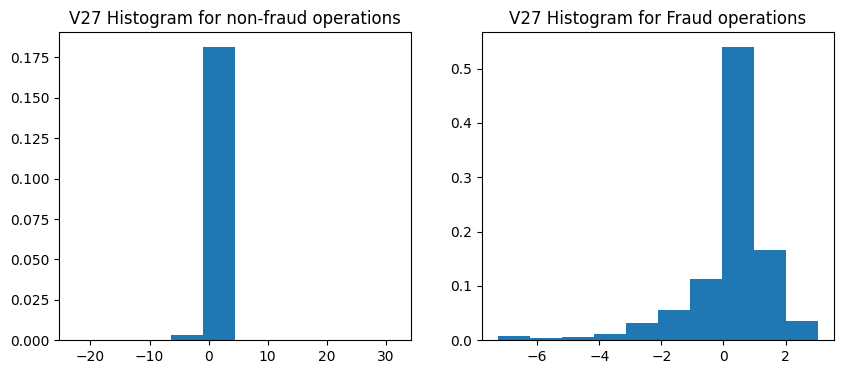

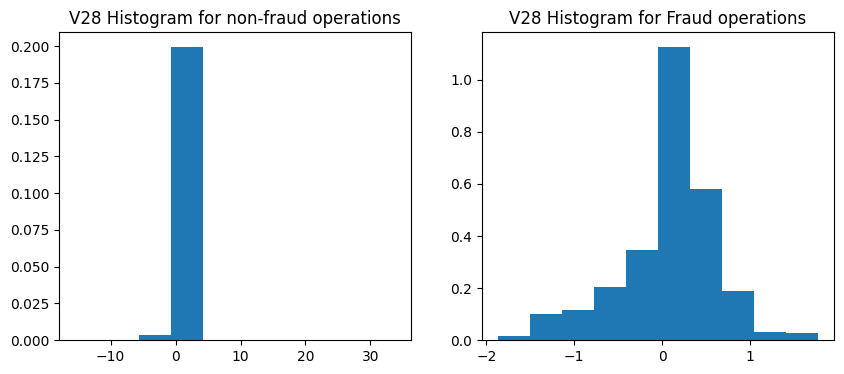

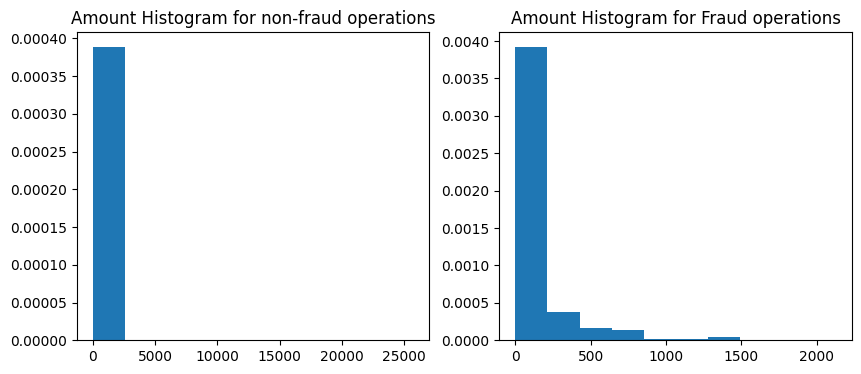

In [10]:
for f in range(len(features)):
    feature_name = features[f]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.hist(df.query('Class == 0')[feature_name], density=True)
    ax1.set_title(feature_name + " Histogram for non-fraud operations")
    ax2.hist(df.query('Class == 1')[feature_name], density=True)
    ax2.set_title(feature_name + " Histogram for Fraud operations")
    plt.show()

The features that I noticed that were importante are Amount of the transaction, V28, V20, V6, V2, since theres a notable variance seen in the histograms, scatter plots and box plots above

### Data Pre Processing

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features], Y, test_size=0.33, random_state=42)

After spliting the data sets into train & test groups, I will pre process this data making a pipeline that
1. Scale the data so every parameter is scaled
2. Get rid of the features with low variance
3. Selects which features have better relation with the target

But before anything I noticed that the amount of the transaction is clearly an outlier, because lets imagine most of the transactions are between 1 dll - 2000 dlls, and some dude transfers half a million dollar, the average of the amount goes nuts and the standard deviation also gets imbalanced a lot by only one transaction.

That's why I'll be transforming the amount column and using the robust scaler so those outliers don't mess up my models

In [64]:
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer

# Create the personalized transformer for the amount
amount_col = ['Amount']
other_features = [col for col in features if col != 'Amount']

# Transformer for amount
log_transformer = FunctionTransformer(
    func=np.log1p,
    validate=False
)

# Scale every other column with RobustScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('amount_log', log_transformer, amount_col),
        ('other_scaling', RobustScaler(), other_features)
    ],
    remainder='drop'
)


# Create reusable pipeline
preprocessPipeline = Pipeline([
    ('preprocessor', preprocessor),
    # I got the k = 20 from testing each one on logistic reggression
    ('selector', SelectKBest(f_classif, k=20))
])

preprocessPipeline.fit(X_train, y_train)

X_train_basic_processed = preprocessPipeline.transform(X_train)
X_test_basic_processed = preprocessPipeline.transform(X_test)

### Supervised Baseline

Now to have a good model as a baseline i'll train a logistic regression and a random forest

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     93838
           1       0.06      0.91      0.11       149

    accuracy                           0.98     93987
   macro avg       0.53      0.94      0.55     93987
weighted avg       1.00      0.98      0.99     93987

ROC-AUC: 0.9812760989916794
PR-AUC SCORE:  0.7684675094981959


/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


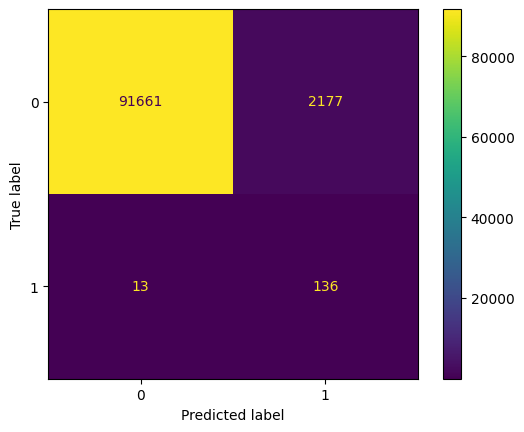

Linear Regression Score: 99.96169683041272


In [86]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1,
    solver='liblinear',
    random_state=42
)

lr.fit(X_train_basic_processed, y_train)

y_pred = lr.predict(X_test_basic_processed)
y_proba = lr.predict_proba(X_test_basic_processed)[:, 1]
pr_auc = average_precision_score(y_test, y_proba)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC SCORE: ", pr_auc)

#Plot Confussion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot()
plt.show()

print("Linear Regression Score:", rf.score(X_test_basic_processed, y_test) * 100)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93838
           1       0.97      0.79      0.87       149

    accuracy                           1.00     93987
   macro avg       0.98      0.89      0.93     93987
weighted avg       1.00      1.00      1.00     93987

ROC-AUC: 0.9545920993927705
PR-AUC: 0.8459556466160971


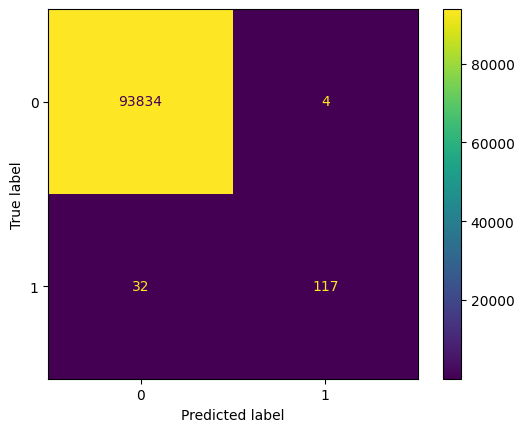

Random Forest Score: 99.96169683041272


In [87]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_basic_processed, y_train)

y_pred = rf.predict(X_test_basic_processed)
y_proba = rf.predict_proba(X_test_basic_processed)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)

disp.plot()
plt.show()

print("Random Forest Score:", rf.score(X_test_basic_processed, y_test) * 100)

### Export Final Pipeline

In [90]:
import joblib

final_pipeline = Pipeline([('preprocesor', preprocessPipeline), ('model', rf)])
joblib.dump(final_pipeline, "fraud_detection_pipeline.pkl")


['fraud_detection_pipeline.pkl']